In [ ]:
from pathlib import Path

import numpy as np
import optuna
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.tree import DecisionTreeClassifier

# El target fue generado en tomas_target_sql.ipynb.
TARGET = "clase_ternaria"
MESES_EVALUACION = [202104, 202106]
SEMILLA = 42
N_TRIALS = 30
GANANCIA_ACIERTO = 1_072_500
COSTO_ESTIMULO = 27_500

# Funciona desde el repositorio local, VS Code o Google Colab con Drive montado.
RUTAS_DATASET = [
    Path("data/competencia_01.csv"),
    Path("/Users/thenseler/Documents/Maestria/DMEyF/dmeyf2026/data/competencia_01.csv"),
    Path("/content/drive/MyDrive/DMEyF/2026/notebooks/data/competencia_01.csv"),
]
DATASET_PATH = next((ruta for ruta in RUTAS_DATASET if ruta.exists()), None)
if DATASET_PATH is None:
    raise FileNotFoundError(
        "No se encontro data/competencia_01.csv. Ejecuta primero tomas_target_sql.ipynb."
    )

data = pd.read_csv(DATASET_PATH)
data = data.loc[data["foto_mes"].isin(MESES_EVALUACION)].copy()
data = data.dropna(subset=[TARGET])

# El identificador no aporta informacion generalizable y foto_mes se usa solo para comparar meses.
FEATURES = [col for col in data.columns if col not in {TARGET, "numero_de_cliente", "foto_mes"}]

print(f"Dataset: {DATASET_PATH}")
print(f"Filas evaluables: {len(data):,}")
print(f"Trials de Optuna por mes: {N_TRIALS}")
print("Distribucion del target por mes (%):")
display(
    data.groupby("foto_mes")[TARGET]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("porcentaje")
)

/Users/thenseler/Documents/Maestria/DMEyF/dmeyf2026/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset: /Users/thenseler/Documents/Maestria/DMEyF/dmeyf2026/data/competencia_01.csv
Filas evaluables: 327,398
Trials de Optuna por mes: 30
Distribucion del target por mes (%):


foto_mes  clase_ternaria
202104    CONTINUA          98.71
          BAJA+2             0.70
          BAJA+1             0.59
202106    CONTINUA          98.80
          BAJA+2             0.67
          BAJA+1             0.53
Name: porcentaje, dtype: float64

# Distribución de ganancias para distintos modelos

Este Colab usa el archivo `competencia_01.csv` creado en `tomas_target_sql.ipynb`. El objetivo (`Y`) es `clase_ternaria`; se comparan configuraciones cambiando hiperparámetros del árbol y el conjunto de variables `X`.

In [3]:
def ganancia(model, X, y, prop=1, threshold=0.025):
    """Calcula la ganancia de contactar clientes con probabilidad alta de BAJA+2."""
    class_index = np.flatnonzero(model.classes_ == "BAJA+2")
    if len(class_index) == 0:
        return 0.0

    prob_baja_2 = model.predict_proba(X)[:, class_index[0]]
    y_array = np.asarray(y)
    aciertos = (prob_baja_2 >= threshold) & (y_array == "BAJA+2")
    costos = (prob_baja_2 >= threshold) & (y_array != "BAJA+2")

    return (GANANCIA_ACIERTO * aciertos.sum() - COSTO_ESTIMULO * costos.sum()) / prop

In [4]:
# Un solo modelo: todas_X. Optuna busca sus hiperparametros por mes.
X_CONFIG = FEATURES

resultados_lista = []
trials_lista = []
parametros_optimos = {}

for mes in MESES_EVALUACION:
    data_mes = data.loc[data["foto_mes"].eq(mes)]
    X_mes = data_mes[X_CONFIG].fillna(0)
    y_mes = data_mes[TARGET]

    splitter_externo = StratifiedShuffleSplit(
        n_splits=1,
        test_size=0.30,
        random_state=SEMILLA,
    )
    train_index, test_index = next(splitter_externo.split(X_mes, y_mes))
    X_train = X_mes.iloc[train_index]
    y_train = y_mes.iloc[train_index]
    X_test = X_mes.iloc[test_index]
    y_test = y_mes.iloc[test_index]

    splitter_validacion = StratifiedShuffleSplit(
        n_splits=1,
        test_size=0.25,
        random_state=SEMILLA,
    )
    ajuste_index, validacion_index = next(
        splitter_validacion.split(X_train, y_train)
    )
    proporcion_validacion = len(validacion_index) / len(X_mes)

    def objetivo(trial):
        params = {
            "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
            "max_depth": trial.suggest_int("max_depth", 2, 12),
            "min_samples_split": trial.suggest_int("min_samples_split", 20, 300),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 150),
        }
        model = DecisionTreeClassifier(random_state=SEMILLA, **params)
        model.fit(X_train.iloc[ajuste_index], y_train.iloc[ajuste_index])
        ganancia_validacion = ganancia(
            model,
            X_train.iloc[validacion_index],
            y_train.iloc[validacion_index],
            prop=proporcion_validacion,
        )
        trial.set_user_attr("Mes", mes)
        return ganancia_validacion

    estudio = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEMILLA),
    )
    estudio.optimize(objetivo, n_trials=N_TRIALS, show_progress_bar=False)
    parametros_optimos[mes] = estudio.best_params

    trials_mes = estudio.trials_dataframe()
    trials_mes["Mes"] = mes
    trials_mes["Ganancia_millones"] = trials_mes["value"] / 1_000_000
    trials_lista.append(trials_mes[["number", "Mes", "Ganancia_millones", "state"]])

    modelo_final = DecisionTreeClassifier(
        random_state=SEMILLA,
        **estudio.best_params,
    )
    modelo_final.fit(X_train, y_train)

    resultados_lista.extend([
        {
            "Mes": mes,
            "Modelo": "DecisionTree + Optuna",
            "Conjunto": "Train",
            "Ganancia": ganancia(modelo_final, X_train, y_train, prop=0.70),
        },
        {
            "Mes": mes,
            "Modelo": "DecisionTree + Optuna",
            "Conjunto": "Test",
            "Ganancia": ganancia(modelo_final, X_test, y_test, prop=0.30),
        },
    ])

resultados = pd.DataFrame(resultados_lista)
trials_optuna = pd.concat(trials_lista, ignore_index=True)
print("Parametros optimos por mes:")
display(pd.DataFrame(parametros_optimos).T)
print("Resultados finales:")
display(resultados)



[I 2026-08-24 21:14:25,513] A new study created in memory with name: no-name-a946565e-febd-459e-bc4e-0e3e15b36532
[I 2026-08-24 21:14:28,136] Trial 0 finished with value: 439995380.5774278 and parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 188, 'min_samples_leaf': 27}. Best is trial 0 with value: 439995380.5774278.
[I 2026-08-24 21:14:30,895] Trial 1 finished with value: 398510101.8372703 and parameters: {'criterion': 'gini', 'max_depth': 11, 'min_samples_split': 188, 'min_samples_leaf': 108}. Best is trial 0 with value: 439995380.5774278.
[I 2026-08-24 21:14:33,564] Trial 2 finished with value: 434181155.9055118 and parameters: {'criterion': 'entropy', 'max_depth': 11, 'min_samples_split': 79, 'min_samples_leaf': 31}. Best is trial 0 with value: 439995380.5774278.
[I 2026-08-24 21:14:35,703] Trial 3 finished with value: 468752221.5223097 and parameters: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_split': 141, 'min_samples_leaf': 47}. Best is trial

Parametros optimos por mes:


,criterion,max_depth,min_samples_split,min_samples_leaf
202104,entropy,7,79,88
202106,entropy,2,275,42


Resultados finales:


,Mes,Modelo,Conjunto,Ganancia
0,202104,DecisionTree + Optuna,Train,5.407679e+08
1,202104,DecisionTree + Optuna,Test,4.376167e+08
2,202106,DecisionTree + Optuna,Train,3.320036e+08
3,202106,DecisionTree + Optuna,Test,2.483250e+08


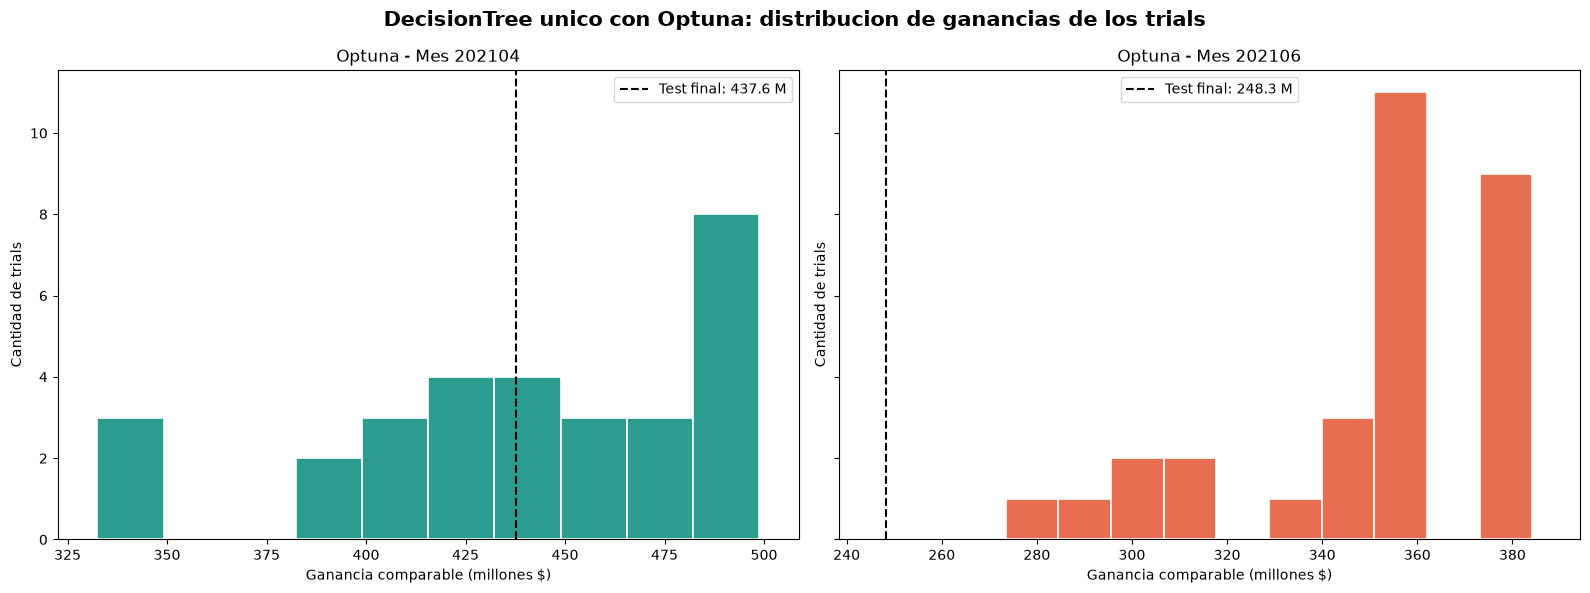

Ganancia final en Test:


,Mes,Modelo,Conjunto,Ganancia
1,202104,DecisionTree + Optuna,Test,4.376167e+08
3,202106,DecisionTree + Optuna,Test,2.483250e+08


In [7]:
# Distribucion de ganancias de los trials de Optuna, un histograma por mes.
colores_meses = {202104: "#2a9d8f", 202106: "#e76f51"}
fig, axes = plt.subplots(1, len(MESES_EVALUACION), figsize=(16, 6), sharey=True)
axes = np.atleast_1d(axes)

for ax, mes in zip(axes, MESES_EVALUACION):
    datos_mes = trials_optuna.loc[trials_optuna["Mes"].eq(mes)]
    ganancia_test_mes = (
        resultados.loc[
            (resultados["Mes"].eq(mes)) & resultados["Conjunto"].eq("Test"),
            "Ganancia",
        ].iloc[0]
        / 1_000_000
    )
    valores_grafico = datos_mes["Ganancia_millones"].to_numpy()
    valores_grafico = np.append(valores_grafico, ganancia_test_mes)
    margen = 10

    ax.hist(
        datos_mes["Ganancia_millones"],
        bins=10,
        color=colores_meses[mes],
        edgecolor="white",
        linewidth=1.2,
    )
    ax.axvline(
        ganancia_test_mes,
        color="black",
        linestyle="--",
        label=f"Test final: {ganancia_test_mes:.1f} M",
    )
    ax.set_xlim(valores_grafico.min() - margen, valores_grafico.max() + margen)
    ax.set_title(f"Optuna - Mes {mes}")
    ax.set_xlabel("Ganancia comparable (millones $)")
    ax.set_ylabel("Cantidad de trials")
    ax.legend()

fig.suptitle(
    "DecisionTree unico con Optuna: distribucion de ganancias de los trials",
    fontsize=15,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

print("Ganancia final en Test:")
resultados.loc[resultados["Conjunto"].eq("Test")]


In [5]:
# Visualizacion del estudio actual de Optuna, sin ejecutar nuevos trials.
# `estudio` queda asociado al ultimo mes procesado por la celda anterior.
fig_contour = optuna.visualization.plot_contour(
    estudio,
    params=["max_depth", "min_samples_leaf"],
)
fig_contour.show()